In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
df = pd.read_csv('/content/maternal_data.csv')
df.head()

,age,bmi,blood_pressure,gestational_age,previous_c_section,previous_miscarriages,previous_preterm_birth,chronic_hypertension,diabetes,gestational_diabetes,preeclampsia_history,multiple_pregnancy,smoking,alcohol_use,family_history,hb_level,urine_protein,blood_glucose,risk_level
0,43,25.845982,121/93,22,0,0,0,1,0,0,0,0,0,1,0,10.047393,5.848787,73.999396,high
1,29,19.596928,136/80,24,1,2,0,0,0,0,0,0,0,0,0,12.667627,42.236787,96.115119,moderate
2,22,19.836580,139/82,30,0,0,0,1,0,1,0,1,0,0,0,12.246688,17.901236,77.634476,high
3,35,27.724191,90/63,8,0,0,0,0,1,0,0,0,1,0,0,11.231405,15.708996,65.107071,high
4,33,22.450612,128/75,19,0,2,0,0,0,0,0,0,0,0,0,12.444657,11.337023,60.000000,moderate


In [ ]:
df.shape

(76645, 19)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76645 entries, 0 to 76644
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   age                     76645 non-null  int64  
 1   bmi                     76645 non-null  float64
 2   blood_pressure          76645 non-null  object 
 3   gestational_age         76645 non-null  int64  
 4   previous_c_section      76645 non-null  int64  
 5   previous_miscarriages   76645 non-null  int64  
 6   previous_preterm_birth  76645 non-null  int64  
 7   chronic_hypertension    76645 non-null  int64  
 8   diabetes                76645 non-null  int64  
 9   gestational_diabetes    76645 non-null  int64  
 10  preeclampsia_history    76645 non-null  int64  
 11  multiple_pregnancy      76645 non-null  int64  
 12  smoking                 76645 non-null  int64  
 13  alcohol_use             76645 non-null  int64  
 14  family_history          76645 non-null

In [ ]:
df.isnull().sum()

,0
age,0
bmi,0
blood_pressure,0
gestational_age,0
previous_c_section,0
previous_miscarriages,0
previous_preterm_birth,0
chronic_hypertension,0
diabetes,0
gestational_diabetes,0


In [ ]:
df.duplicated().sum()

np.int64(0)

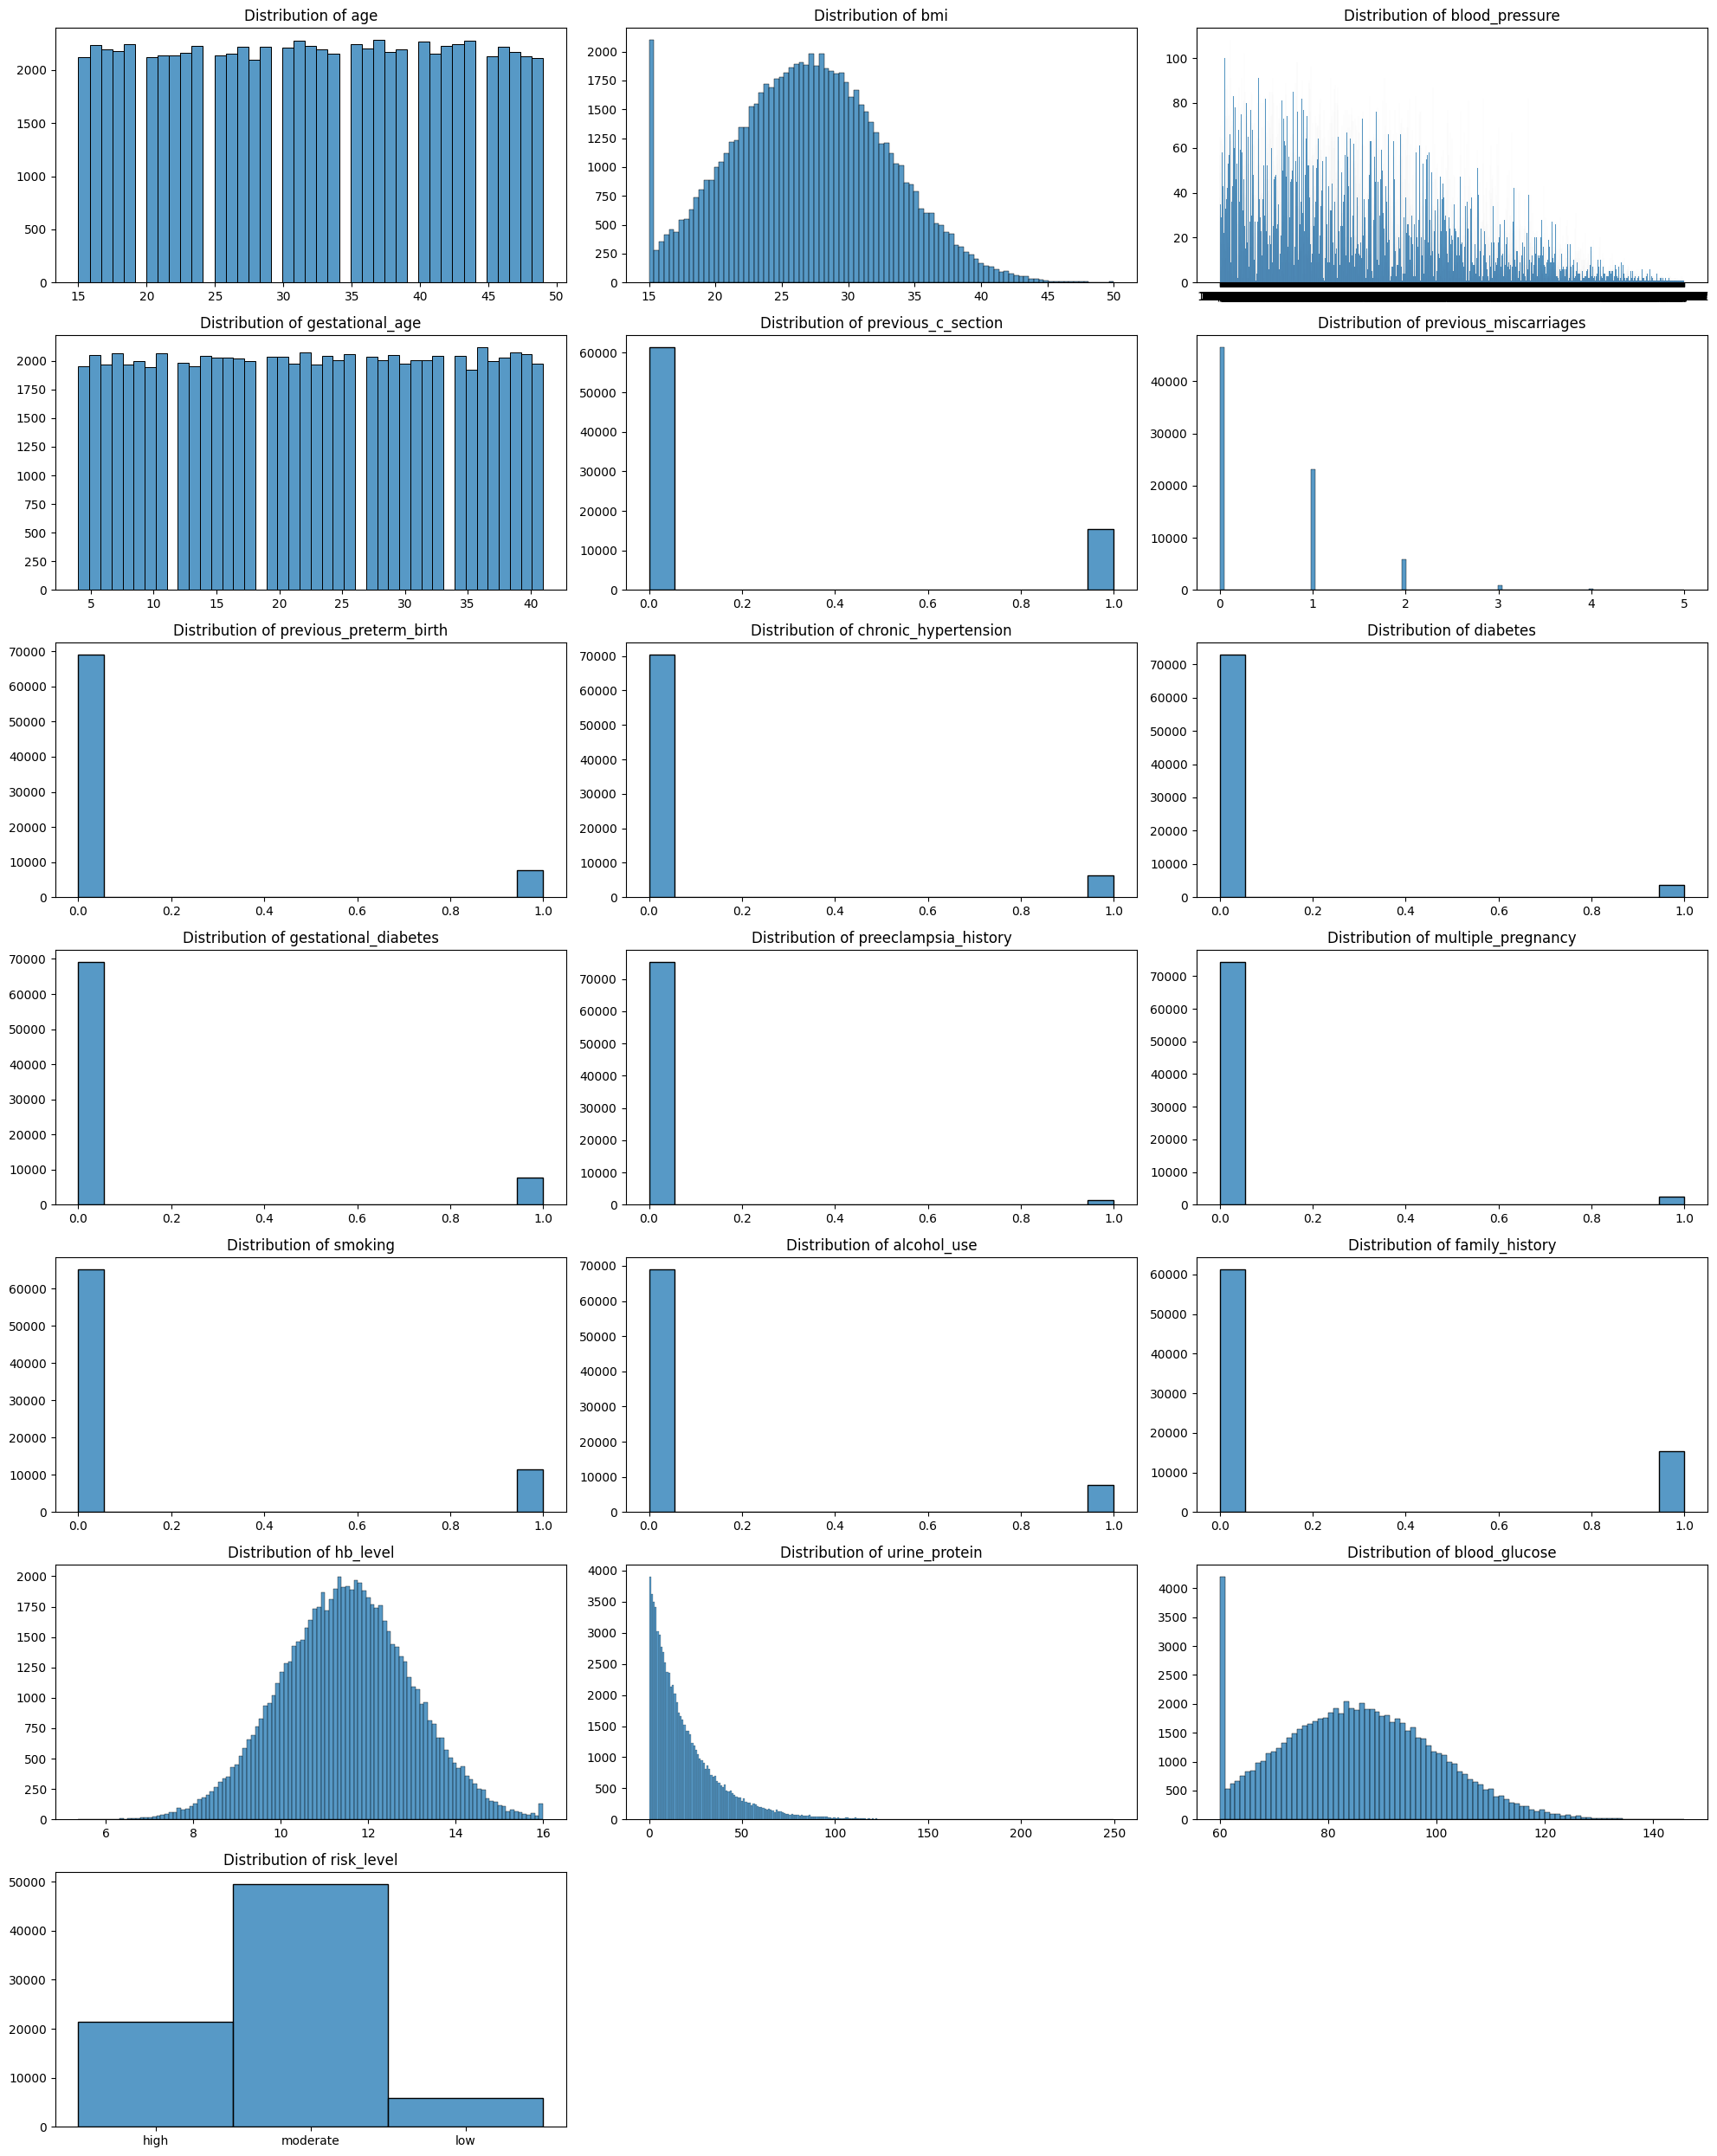

In [ ]:
plt.figure(figsize=(20, 25))
feature_columns = df.columns

for i, column in enumerate(feature_columns, 1):
    plt.subplot(7, 3, i)
    sns.histplot(df[column])
    plt.title(f'Distribution of {column}')
    plt.xlabel('')
    plt.ylabel('')
plt.tight_layout()
plt.show()

In [ ]:
label_encoder = LabelEncoder()
df['risk_level'] = label_encoder.fit_transform(df['risk_level'])
df.head()

,age,bmi,blood_pressure,gestational_age,previous_c_section,previous_miscarriages,previous_preterm_birth,chronic_hypertension,diabetes,gestational_diabetes,preeclampsia_history,multiple_pregnancy,smoking,alcohol_use,family_history,hb_level,urine_protein,blood_glucose,risk_level
0,43,25.845982,121/93,22,0,0,0,1,0,0,0,0,0,1,0,10.047393,5.848787,73.999396,0
1,29,19.596928,136/80,24,1,2,0,0,0,0,0,0,0,0,0,12.667627,42.236787,96.115119,2
2,22,19.836580,139/82,30,0,0,0,1,0,1,0,1,0,0,0,12.246688,17.901236,77.634476,0
3,35,27.724191,90/63,8,0,0,0,0,1,0,0,0,1,0,0,11.231405,15.708996,65.107071,0
4,33,22.450612,128/75,19,0,2,0,0,0,0,0,0,0,0,0,12.444657,11.337023,60.000000,2


In [ ]:
df[['systolic', 'diastolic']] = df['blood_pressure'].str.split('/', expand=True)
df['systolic'] = pd.to_numeric(df['systolic'], errors='coerce')
df['diastolic'] = pd.to_numeric(df['diastolic'], errors='coerce')
df = df.drop('blood_pressure', axis=1)

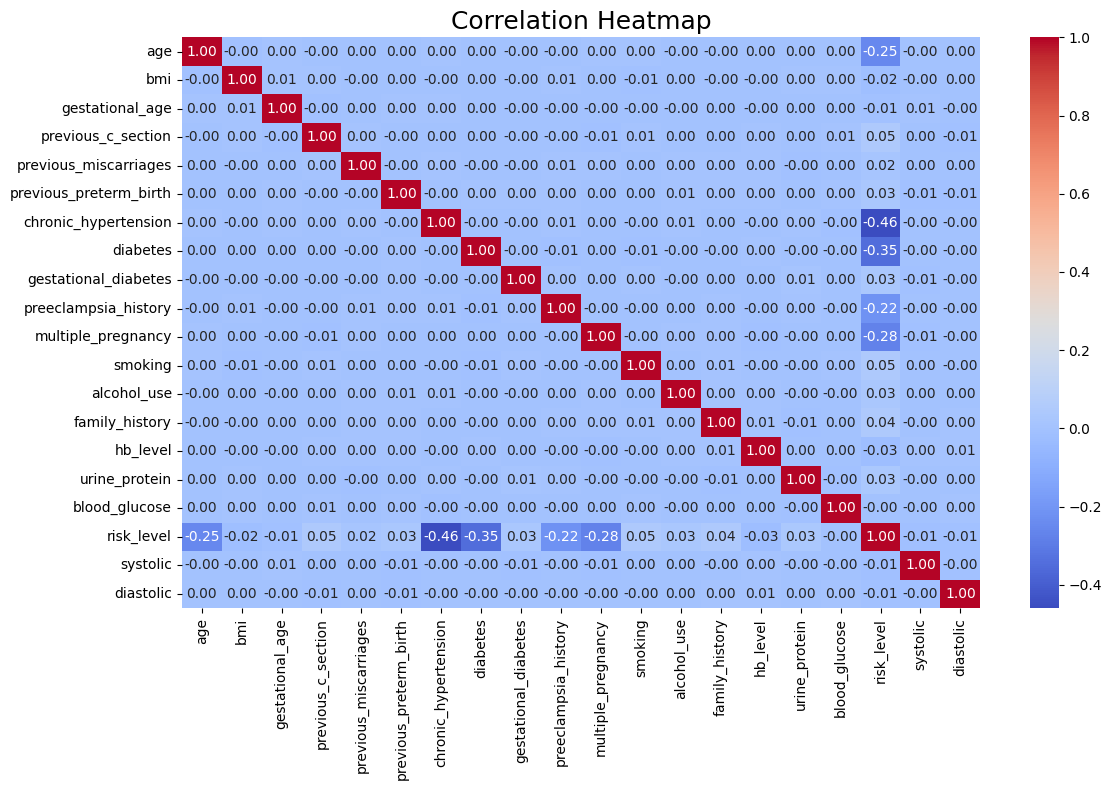

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt = '.2f')
plt.title("Correlation Heatmap", fontsize=18)
plt.tight_layout()
plt.show()

In [ ]:
df.drop(['multiple_pregnancy', 'smoking', 'alcohol_use', 'family_history'], axis=1, inplace=True)
df.head()

,age,bmi,gestational_age,previous_c_section,previous_miscarriages,previous_preterm_birth,chronic_hypertension,diabetes,gestational_diabetes,preeclampsia_history,hb_level,urine_protein,blood_glucose,risk_level,systolic,diastolic
0,43,25.845982,22,0,0,0,1,0,0,0,10.047393,5.848787,73.999396,0,121,93
1,29,19.596928,24,1,2,0,0,0,0,0,12.667627,42.236787,96.115119,2,136,80
2,22,19.836580,30,0,0,0,1,0,1,0,12.246688,17.901236,77.634476,0,139,82
3,35,27.724191,8,0,0,0,0,1,0,0,11.231405,15.708996,65.107071,0,90,63
4,33,22.450612,19,0,2,0,0,0,0,0,12.444657,11.337023,60.000000,2,128,75


In [ ]:
X = df.drop('risk_level', axis=1)
y = df['risk_level']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

LR_accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {LR_accuracy:.2f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.86

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.78      0.86      4246
           1       0.55      0.25      0.34      1170
           2       0.84      0.97      0.90      9913

    accuracy                           0.86     15329
   macro avg       0.79      0.66      0.70     15329
weighted avg       0.85      0.86      0.85     15329



In [ ]:
model = DecisionTreeClassifier()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

DT_accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {DT_accuracy:.2f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.89

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.92      0.91      4246
           1       0.60      0.57      0.59      1170
           2       0.92      0.92      0.92      9913

    accuracy                           0.89     15329
   macro avg       0.81      0.80      0.81     15329
weighted avg       0.89      0.89      0.89     15329



In [ ]:
model = XGBClassifier()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

XG_accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {XG_accuracy:.2f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.92

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.91      0.95      4246
           1       0.60      0.85      0.70      1170
           2       0.95      0.94      0.94      9913

    accuracy                           0.92     15329
   macro avg       0.85      0.90      0.87     15329
weighted avg       0.94      0.92      0.93     15329



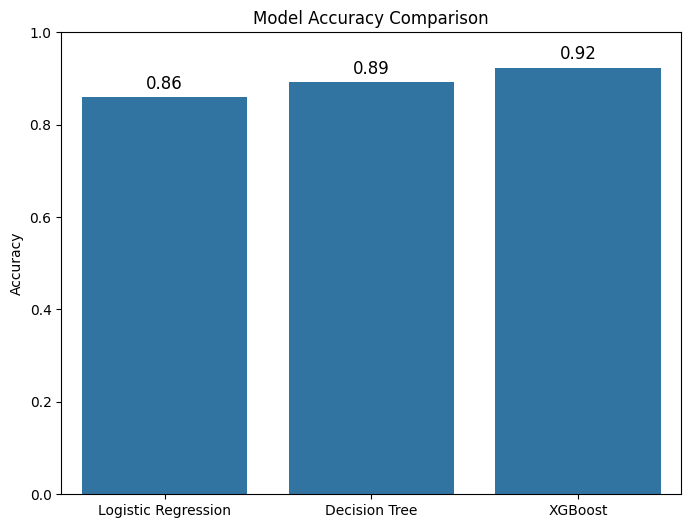

In [ ]:
model_accuracies = {'Logistic Regression': LR_accuracy, 'Decision Tree': DT_accuracy, 'XGBoost': XG_accuracy}
plt.figure(figsize=(8, 6))
sns.barplot(x=list(model_accuracies.keys()), y=list(model_accuracies.values()))
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
for i, (model, accuracy) in enumerate(model_accuracies.items()):
    plt.text(i, accuracy + 0.01, f"{accuracy:.2f}", ha='center', va='bottom', fontsize=12)
plt.show()